In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile, os
import pandas as pd
import os
import torchaudio
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
from transformers import HubertModel

Завантаження датасету:

In [8]:
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/timit'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

Зчитування CSV-файлів з інформацією про структуру датасету:

In [9]:
train_csv = pd.read_csv('/content/timit/train_data.csv')
test_csv = pd.read_csv('/content/timit/test_data.csv')

BASE_DIR = '/content/timit/data'

train_audio = train_csv[train_csv['is_audio'] == True].reset_index(drop=True)
test_audio = test_csv[test_csv['is_audio'] == True].reset_index(drop=True)

Формування списків train_pairs та test_pairs для подальшої обробки:

In [10]:
def get_wav_phn_pairs(audio_df, base_dir):
    pairs = []
    for _, row in audio_df.iterrows():
        wav_path = os.path.join(base_dir, row['path_from_data_dir'])
        wav_name = row['filename']
        base_name = wav_name.replace('.WAV.wav', '').replace('.wav', '')
        phn_name = base_name + '.PHN'

        phn_path = os.path.join(
            base_dir,
            row['path_from_data_dir'].replace(wav_name, phn_name)
        )

        if os.path.exists(wav_path) and os.path.exists(phn_path):
            pairs.append({'wav': wav_path, 'phn': phn_path})

    return pairs

train_pairs = get_wav_phn_pairs(train_audio, BASE_DIR)
test_pairs = get_wav_phn_pairs(test_audio, BASE_DIR)

Кожна фонема описана трьома значеннями: номер початкового семпла, номер кінцевого семпла та назва фонеми.

Ця функція зчитує файл рядок за рядком, витягує ці значення та приводить назву фонеми до нижнього регістру для уніфікації.

In [11]:
def parse_phn_file(phn_path):
    phonemes = []
    with open(phn_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, phone = int(parts[0]), int(parts[1]), parts[2].lower()
                phonemes.append((start, end, phone))
    return phonemes

In [57]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
device = "cuda" if torch.cuda.is_available() else "cpu"

Формування повного списку фонем та створення функції для мапінгу кожної секунди аудіо до конкретного ID фонеми:

In [58]:
ALL_PHONEMES = sorted(list(set(
    phone
    for pair in train_pairs + test_pairs
    for _, _, phone in parse_phn_file(pair['phn'])
)))
phoneme2id = {p: i for i, p in enumerate(ALL_PHONEMES)}
NUM_CLASSES = len(ALL_PHONEMES)

def get_frame_labels(phn_path, num_frames, hop=320):
    phonemes = parse_phn_file(phn_path)
    labels = []
    for i in range(num_frames):
        center = i * hop + hop // 2
        label = 0
        for start, end, phone in phonemes:
            if start <= center < end:
                label = phoneme2id.get(phone, 0)
                break
        labels.append(label)
    return torch.tensor(labels, dtype=torch.long)

Побудова та налаштування класифікатора:

In [60]:
class PhonemeClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=NUM_CLASSES):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [61]:
def collate_fn(batch):
    features, labels = zip(*batch)
    max_len = max(f.shape[0] for f in features)

    padded_features = torch.zeros(len(features), max_len, 768)
    padded_labels = torch.full((len(features), max_len), -100, dtype=torch.long)

    for i, (f, l) in enumerate(zip(features, labels)):
        padded_features[i, :f.shape[0]] = f
        padded_labels[i, :l.shape[0]] = l

    return padded_features, padded_labels

Функція для запуску експериментів:

In [67]:
def run_experiment(pairs_train, pairs_test, feature_fn, name, epochs=10):
    print(f"\n{'='*50}")
    print(f"Експеримент: {name}")
    print(f"{'='*50}")

    class ExpDataset(Dataset):
        def __init__(self, pairs):
            self.pairs = pairs
        def __len__(self):
            return len(self.pairs)
        def __getitem__(self, idx):
            p = self.pairs[idx]
            features = feature_fn(p['wav'])
            labels = get_frame_labels(p['phn'], features.shape[0])
            return features, labels

    tr_loader = DataLoader(ExpDataset(pairs_train), batch_size=16,
                           shuffle=True, collate_fn=collate_fn, num_workers=0)
    te_loader = DataLoader(ExpDataset(pairs_test), batch_size=16,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

    model = PhonemeClassifier().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss(ignore_index=-100)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for features, labels in tqdm(tr_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            features, labels = features.to(device), labels.to(device)
            loss = crit(model(features).permute(0, 2, 1), labels)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(tr_loader):.4f}")

    per = compute_per(te_loader, model)
    print(f"\n>>> {name} | PER: {per*100:.2f}%")
    return per

In [63]:
def compute_per(loader, model):
    model.eval()
    total_errors = 0
    total_frames = 0

    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Evaluating"):
            features = features.to(device)
            logits = model(features)
            preds = logits.argmax(dim=-1).cpu()

            for pred_seq, label_seq in zip(preds, labels):
                mask = label_seq != -100
                pred_seq = pred_seq[mask]
                label_seq = label_seq[mask]

                errors = (pred_seq != label_seq).sum().item()
                total_errors += errors
                total_frames += len(label_seq)

    return total_errors / total_frames if total_frames > 0 else 1.0

In [14]:
!pip install noisereduce -q

In [15]:
!pip install pesq pystoi -q

  Preparing metadata (setup.py) ... done


In [19]:
import numpy as np
import torchaudio.functional as AF
import noisereduce as nr
from pesq import pesq
from pystoi import stoi
from tqdm import tqdm

## Функції для аудіофільтрації:

### *1*) Pre-emphasis

Формула: y[t] = x[t] - alpha * x[t-1]

Підсилює високі частоти

In [1]:
def filter_preemphasis(audio_np, sr, alpha=0.97):
    emphasized = np.append(audio_np[0], audio_np[1:] - alpha * audio_np[:-1])
    return emphasized

### 2) High-pass filter

Прибирає частоти нижче cutoff_freq Гц

Корисно проти низькочастотного гулу

In [4]:
def filter_highpass(audio_np, sr, cutoff_freq=80.0):
    waveform_t = torch.tensor(audio_np).float().unsqueeze(0)
    filtered = AF.highpass_biquad(waveform_t, sr, cutoff_freq=cutoff_freq)
    return filtered.squeeze(0).numpy()

### 3) Spectral noise reduction

Оцінює профіль шуму з тихих ділянок і віднімає його

In [2]:
def filter_noise_reduction(audio_np, sr):
    reduced = nr.reduce_noise(
        y=audio_np,
        sr=sr,
        stationary=True,
        prop_decrease=0.75
    )
    return reduced

### 4) Нормалізація гучності (Peak normalization)

Приводить всі файли до однакового рівня гучності

In [3]:
def filter_normalize(audio_np, target_level=0.95):
    max_val = np.abs(audio_np).max()
    if max_val > 0:
        return audio_np / max_val * target_level
    return audio_np

Функція для завантаження та вибору фільтрів:

In [18]:
def load_and_filter(wav_path, use_preemphasis=False, use_highpass=False,
                    use_noise_reduction=False, use_normalization=False):
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)
        sr = 16000

    audio = waveform.squeeze(0).numpy()

    if use_noise_reduction:
        audio = filter_noise_reduction(audio, sr)
    if use_highpass:
        audio = filter_highpass(audio, sr)
    if use_preemphasis:
        audio = filter_preemphasis(audio, sr)
    if use_normalization:
        audio = filter_normalize(audio)

    return audio, sr

audio_orig, sr = load_and_filter(train_pairs[0]['wav'])
audio_all, sr  = load_and_filter(train_pairs[0]['wav'],
                                  use_preemphasis=True,
                                  use_highpass=True,
                                  use_noise_reduction=True,
                                  use_normalization=True)
print(f"Оригінал: max={np.abs(audio_orig).max():.4f}, std={audio_orig.std():.4f}")
print(f"Всі фільтри: max={np.abs(audio_all).max():.4f}, std={audio_all.std():.4f}")

Оригінал: max=0.0561, std=0.0053
Всі фільтри: max=0.9500, std=0.0523


Обчислення метрик SNR, PESQ, STOI до і після фільтрації:
(тестування на 50 файлах)

In [41]:
def compute_quality_metrics(wav_path, filter_kwargs):
    audio_orig, sr = load_and_filter(wav_path)
    audio_filt, sr = load_and_filter(wav_path, **filter_kwargs)

    min_len = min(len(audio_orig), len(audio_filt))
    audio_orig = audio_orig[:min_len]
    audio_filt = audio_filt[:min_len]

    noise = audio_filt - audio_orig
    signal_power = np.mean(audio_orig ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-10))

    try:
        pesq_score = pesq(sr, audio_orig, audio_filt, 'wb')
    except:
        pesq_score = None

    try:
        stoi_score = stoi(audio_orig, audio_filt, sr, extended=False)
    except:
        stoi_score = None

    return {'SNR': snr, 'PESQ': pesq_score, 'STOI': stoi_score}

filter_config = dict(use_preemphasis=True, use_highpass=True,
                     use_noise_reduction=True, use_normalization=True)

metrics_list = []
for pair in test_pairs[:50]:
    m = compute_quality_metrics(pair['wav'], filter_config)
    metrics_list.append(m)

import pandas as pd
metrics_df = pd.DataFrame(metrics_list)
print("\nСередні метрики якості (всі фільтри):")
print(metrics_df.describe().loc[['mean', 'std']])


Середні метрики якості (всі фільтри):
            SNR      PESQ      STOI
mean -13.633518  4.085764  0.984432
std    4.558787  0.195661  0.004058


In [65]:
hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
hubert.eval()
hubert = hubert.to(device)

def extract_features_filtered(wav_path, filter_kwargs=None):
    if filter_kwargs is None:
        filter_kwargs = {}

    audio, sr = load_and_filter(wav_path, **filter_kwargs)

    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = hubert(input_values)

    return outputs.last_hidden_state.squeeze(0).cpu()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [ ]:
ablation_results = {}
ablation_results['Baseline (no filter)'] = 0.1797

ablation_configs = {
    'Pre-emphasis only':     dict(use_preemphasis=True),
    'High-pass only':        dict(use_highpass=True),
    'Noise reduction only':  dict(use_noise_reduction=True),
    'Normalization only':    dict(use_normalization=True),
    'All filters combined':  dict(use_preemphasis=True,
                                  use_highpass=True,
                                  use_noise_reduction=True,
                                  use_normalization=True),
}

for config_name, filter_kwargs in ablation_configs.items():
    per = run_experiment(
        train_pairs, test_pairs,
        lambda p, fk=filter_kwargs: extract_features_filtered(p, fk),
        config_name,
        epochs=10
    )
    ablation_results[config_name] = per
    print(f"{config_name}: {per*100:.2f}%")


Експеримент: Pre-emphasis only


Epoch 1/10: 100%|██████████| 289/289 [02:19<00:00,  2.08it/s]


Epoch 1 | Loss: 1.0625


Epoch 2/10: 100%|██████████| 289/289 [02:15<00:00,  2.13it/s]


Epoch 2 | Loss: 0.6567


...

Epoch 9 | Loss: 0.5028


Epoch 10/10: 100%|██████████| 289/289 [05:31<00:00,  1.15s/it]


Epoch 10 | Loss: 0.4930


Evaluating: 100%|██████████| 105/105 [02:01<00:00,  1.16s/it]


>>> All filters combined | PER: 18.27%
All filters combined: 18.27%


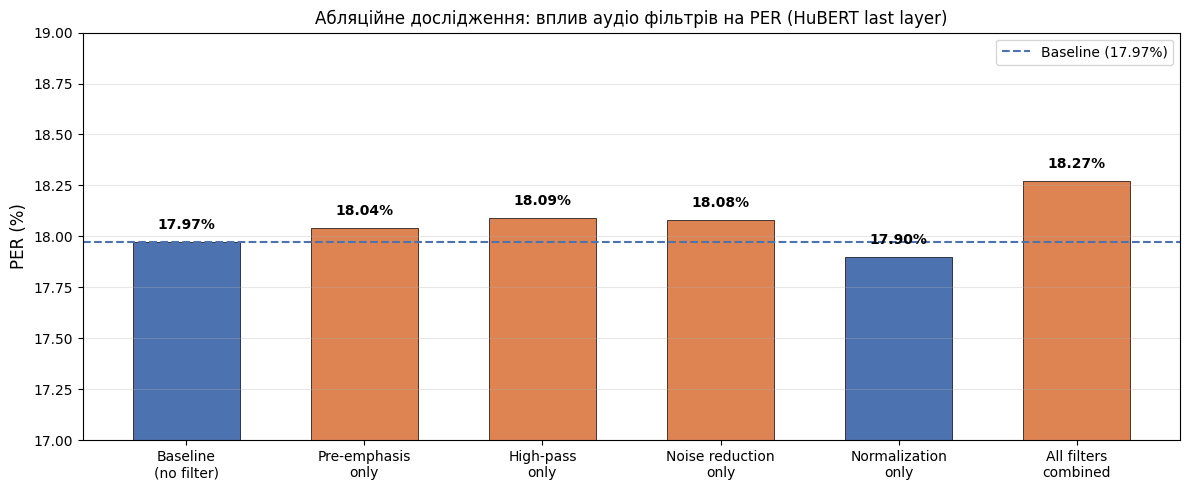

In [45]:
import matplotlib.pyplot as plt
import json

ablation_results = {
    'Baseline\n(no filter)': 17.97,
    'Pre-emphasis\nonly': 18.04,
    'High-pass\nonly': 18.09,
    'Noise reduction\nonly': 18.08,
    'Normalization\nonly': 17.90,
    'All filters\ncombined': 18.27,
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0' if v <= 17.97 else '#DD8452' for v in ablation_results.values()]
bars = ax.bar(ablation_results.keys(), ablation_results.values(),
              color=colors, edgecolor='black', linewidth=0.5, width=0.6)

ax.axhline(y=17.97, color='#4C72B0', linestyle='--', linewidth=1.5,
           label='Baseline (17.97%)')

for bar, val in zip(bars, ablation_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('PER (%)', fontsize=12)
ax.set_title('Абляційне дослідження: вплив аудіо фільтрів на PER (HuBERT last layer)',
             fontsize=12)
ax.set_ylim(17.0, 19.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ablation_study.png', bbox_inches='tight')
plt.show()

In [47]:
from pystoi import stoi

def compute_snr(original, filtered):
    min_len = min(len(original), len(filtered))
    orig, filt = original[:min_len], filtered[:min_len]
    noise = filt - orig
    return 10 * np.log10(np.mean(orig**2) / (np.mean(noise**2) + 1e-10))

def compute_stoi_score(original, filtered, sr=16000):
    min_len = min(len(original), len(filtered))
    try:
        return stoi(original[:min_len], filtered[:min_len], sr, extended=False)
    except:
        return None

configs = {
    'Pre-emphasis':     dict(use_preemphasis=True),
    'High-pass':        dict(use_highpass=True),
    'Noise reduction':  dict(use_noise_reduction=True),
    'Normalization':    dict(use_normalization=True),
    'All combined':     dict(use_preemphasis=True, use_highpass=True,
                             use_noise_reduction=True, use_normalization=True),
}

print(f"{'Фільтр':<20} {'SNR (dB)':>10} {'STOI':>8}")

for name, kwargs in configs.items():
    snrs, stois = [], []
    for pair in tqdm(test_pairs, desc=name):
        orig, sr = load_and_filter(pair['wav'])
        filt, sr = load_and_filter(pair['wav'], **kwargs)
        snrs.append(compute_snr(orig, filt))
        s = compute_stoi_score(orig, filt, sr)
        if s: stois.append(s)

    print(f"{name:<20} {np.mean(snrs):>9.2f}  {np.mean(stois):>7.4f}")

Фільтр                 SNR (dB)     STOI
----------------------------------------


Pre-emphasis: 100%|██████████| 1680/1680 [02:30<00:00, 11.17it/s]


Pre-emphasis              0.26   0.9965


High-pass: 100%|██████████| 1680/1680 [02:25<00:00, 11.56it/s]


High-pass                13.16   0.9993


...

Noise reduction           5.22   0.9887


Normalization: 100%|██████████| 1680/1680 [02:35<00:00, 10.81it/s]


Normalization           -15.72   1.0000


All combined: 100%|██████████| 1680/1680 [03:54<00:00,  7.17it/s]

All combined            -13.75   0.9838


In [48]:
data = {
    'Фільтр':        ['Baseline', 'Pre-emphasis', 'High-pass', 'Noise reduction', 'Normalization', 'All combined'],
    'PER (%)':       [17.97, 18.04, 18.09, 18.08, 17.90, 18.27],
    'Δ PER':         ['-', '+0.07%', '+0.12%', '+0.11%', '-0.07%', '+0.30%'],
    'SNR (dB)':      ['-', '0.26', '13.16', '5.22', '-15.72', '-13.75'],
    'STOI':          ['-', '0.9965', '0.9993', '0.9887', '1.0000', '0.9838'],
}

df = pd.DataFrame(data)
print(df.to_string(index=False))
df.to_csv('/content/drive/MyDrive/final_metrics_table.csv', index=False)

         Фільтр  PER (%)  Δ PER SNR (dB)   STOI
       Baseline    17.97      -        -      -
   Pre-emphasis    18.04 +0.07%     0.26 0.9965
      High-pass    18.09 +0.12%    13.16 0.9993
Noise reduction    18.08 +0.11%     5.22 0.9887
  Normalization    17.90 -0.07%   -15.72 1.0000
   All combined    18.27 +0.30%   -13.75 0.9838
